In [1]:
import numpy as np

info=[]
bonds=[]
with open("LastConfig.bfm", "r") as file:
    data = file.readlines()
    for i,line in enumerate(data):
        if (line.startswith("!") or line.startswith("#!")) and "=" in line:
            textstring = line.strip()[1:]
            name = str(textstring[0:textstring.find("=")])
            value = float(textstring[textstring.find("=")+1:])
            index = i
            info.append([name,value,index])

number_of_monomers = info[1][1]
box_x = info[2][1]
box_y = info[3][1]
box_z = info[4][1]
number_of_linear_chains = info[8][1]
number_of_crosslinkers = info[9][1]
chainLength = info[10][1]
mcs = info[-1][1]

bonds = "".join(data[data.index("!bonds\n")+1:info[2][2]]) #the end is when box x starts
bonds = np.fromstring(bonds,sep=" ",dtype=float).reshape(-1, 2)

bondvectors = "".join(data[data.index("!set_of_bondvectors\n")+1:data.index("!attributes\n")-1])

attributes = "".join(data[data.index("!attributes\n")+1:data.index("!reactivity\n")-1])

reactivity = "".join(data[data.index("!reactivity\n")+1:info[8][2]])

conformations = "".join(data[info[13][2]+1:info[13][2]+1+int(info[8][1])]) #the end is adding the number of chains to the first point

crosslinks = "".join(data[info[13][2]+1+int(info[8][1]):])
crosslinks = np.fromstring(crosslinks,sep=" ",dtype=float).reshape(-1, 3)
       
         

# Checking if crosslink positions and first-monomer positions are changed

In [2]:
a = bonds[:,0]<bonds[:,1]
all(a)

True

# Change from monomers ID to chains ID and xlinks ID

In [2]:
aa = bonds[:,0]-1
chainsID = aa//(chainLength)+1

xlink = bonds[:,1]-chainLength*number_of_linear_chains
bondss = np.array([chainsID,xlink]).T

# Sort by chainsID

In [3]:
sorted_bonds = bondss[bondss[:,0].argsort()]

# Check repeated values and calculate conversion rate

In [5]:
values, counts = np.unique(chainsID, return_counts=True)
conversion = 100*len(counts[counts>1])/len(counts)
conversion

98.13344908842862

# Periodic boundary conditions:

In [5]:
print("Crosslink positions with empty spaces: ", crosslinks[crosslinks == None]) #all crosslinks have 3 numbers in positions

xlink_pbc = np.mod(crosslinks, [box_x,box_y,box_z])

print("Crosslinks outside the box: ", "x: ", any(xlink_pbc[:,0]>box_x), "y :", any(xlink_pbc[:,1]>box_y), "z :", any(xlink_pbc[:,2]>box_z))

Crosslink positions with empty spaces:  []
Crosslinks outside the box:  x:  False y : False z : False


# Save the tables

In [213]:
np.savetxt("bonds.txt",sorted_bonds,fmt="%.0f",delimiter="\t",header="chain\tcrosslink")
np.savetxt("crosslinks.txt",xlink_pbc,fmt="%.0f",delimiter="\t",header="x\ty\tz")

In [217]:
%reset -f

# Find the xlinks connected by each chain

In [ ]:
chains = sorted_bonds[:,0]

# Find unique chains and indices
unique_chains, inverse = np.unique(chains, return_inverse=True)

chains_xlinks = []

for i, chain in enumerate(unique_chains):
    mask = inverse == i  # all rows for this chain
    associated = sorted_bonds[mask, 1]

    if associated.size < 2:  
        continue

    chains_xlinks.append([chain] + associated.tolist())

# Pad to max length
max_len = max(len(r) for r in chains_xlinks)
table1_padded = np.array([r + [np.nan]*(max_len-len(r)) for r in chains_xlinks])

# Save to file
np.savetxt(
    "chains_xlinks.txt",
    table1_padded,
    fmt="%.0f",
    delimiter="\t",
    header="\t".join(["chain"] + [f"xlink{i+1}" for i in range(max_len-1)]),
    comments=""
)

# Find the connected xlinks

In [9]:
chains_xlinks = np.loadtxt("chains_xlinks.txt", skiprows=1, delimiter="\t", dtype=int)
from collections import defaultdict

connections = defaultdict(list)  # xlinkID -> set of connected xlinks

for row in chains_xlinks:
    # Remove NaNs
    xlinks = [int(x) for x in row[1:] if not np.isnan(x)]

    # For all pair combinations in this chain:
    for i in range(len(xlinks)):
        for j in range(i+1, len(xlinks)):
            x1, x2 = xlinks[i], xlinks[j]

            # Add both directions, but KEEP duplicates
            connections[x1].append(x2)
            connections[x2].append(x1)

# Determine padding length
max_len = max(len(v) for v in connections.values())

# Build padded rows
rows = []
for xlink, conn_list in connections.items():
    row = [xlink] + conn_list
    row += [0] * (max_len - len(conn_list))  # pad with zeros
    rows.append(row)

rows = np.array(rows, dtype=int)
header = "\t".join(["xlinkID"] + [f"xlink_{i+1}" for i in range(max_len)])
np.savetxt("connected_xlinks.txt", rows, fmt="%.0f", delimiter="\t", header=header, comments="")


# Minimization of displacements

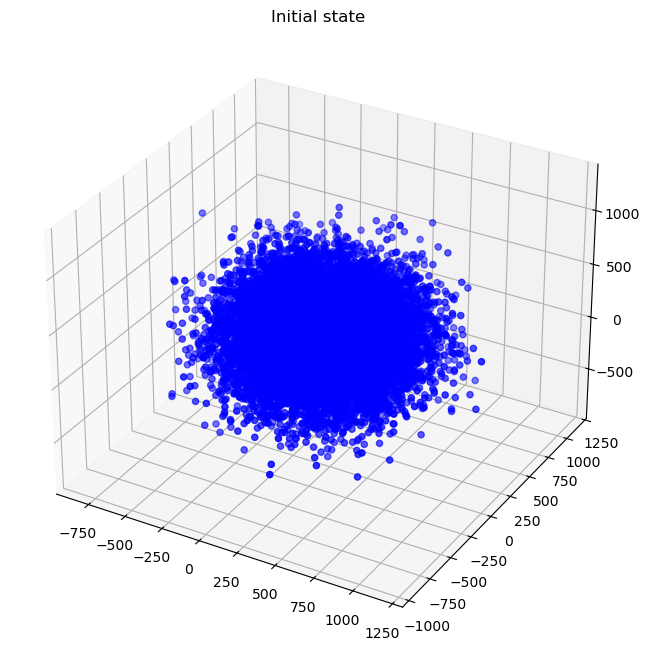

Step 1: max displacement = 3.158189e+01
Step 2: max displacement = 1.420318e+01
Step 3: max displacement = 6.433383e+00
Step 4: max displacement = 5.047247e+00
Step 5: max displacement = 3.117386e+00
Step 6: max displacement = 2.105140e+00
Step 7: max displacement = 1.990359e+00
Step 8: max displacement = 1.270110e+00
Step 9: max displacement = 9.576182e-01
Step 10: max displacement = 8.691881e-01
Step 11: max displacement = 6.657345e-01
Step 12: max displacement = 4.942863e-01
Step 13: max displacement = 4.116797e-01
Step 14: max displacement = 3.825741e-01
Step 15: max displacement = 3.657256e-01
Step 16: max displacement = 3.132170e-01
Step 17: max displacement = 2.949743e-01
Step 18: max displacement = 2.623701e-01
Step 19: max displacement = 2.449440e-01
Step 20: max displacement = 2.353670e-01
Step 21: max displacement = 2.037724e-01
Step 22: max displacement = 1.992875e-01
Step 23: max displacement = 1.747807e-01
Step 24: max displacement = 1.672479e-01
Step 25: max displacement

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
# Load crosslink positions
positions = np.loadtxt("crosslinks-positions.txt")

# Load connection table (first column = ID, next columns = connected IDs)
connections = np.loadtxt("connected_xlinks.txt", skiprows=1, delimiter="\t", dtype=int)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(positions[:,0], positions[:,1], positions[:,2], color='blue')

if False:
    for i, j in bonds:
        x = [positions[i-1,0], positions[j-1,0]]
        y = [positions[i-1,1], positions[j-1,1]]
        z = [positions[i-1,2], positions[j-1,2]]
        ax.plot(x, y, z, color='red') 
plt.title("Initial state")
plt.show()

max_steps = 1000
tolerance = 1e-8  # convergence criterion (adjust as needed)

step = 0
max_displacement = np.inf
# box length (scalar) used in many toy sections above; if you have per-axis boxes use an array like [Lx, Ly, Lz]
L = 256

# make box an array for component-wise ops (works if L is scalar or array)
box = np.asarray(L) if np.ndim(L) > 0 else np.array([L, L, L])

while max_displacement > tolerance and step < max_steps:
    max_displacement = 0.0
    # random update order helps Monte Carlo convergence (Fisher-Yates via np.random.permutation)
    indices = np.random.permutation(len(positions))

    for i in indices:  # run over xlinks
        pos = positions[i] % box

        # accumulate neighbor displacements using minimum-image convention
        sum_delta = np.zeros(pos.shape)
        count = 0

        for j in range(len(connections)):
                    # check if i appears in this bond
            for k in range(len(connections[j])):
                if connections[j][k] == 0: #ignore 0 indices -- no connnection
                    continue
                if int(connections[j][k]) - 1 == i:
                            # map the other positions in the bond
                    for other_idx in range(len(connections[j])):
                        if connections[j][other_idx] == 0: #ignore 0 indices -- no connnection
                            continue
                        if other_idx != k:
                            conn_idx = int(connections[j][other_idx]) - 1
                            conn_pos = positions[conn_idx] % box
                            delta = conn_pos - pos
                            delta = (delta + 0.5 * box) % box - 0.5 * box  # minimum-image
                            sum_delta += delta
                            count += 1

                # compute average displacement
        if count == 0:
            COM = np.zeros_like(pos)
        else:
            COM = sum_delta / count

        new_pos = (pos + COM) % box
        positions[i] = new_pos

        displacement = np.linalg.norm(COM)
        if displacement > max_displacement:
            max_displacement = displacement

    step += 1
    print(f"Step {step}: max displacement = {max_displacement:.6e}")

# optional quick plot of equilibrated positions
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(positions[:,0], positions[:,1], positions[:,2], color='blue')

if False:
    for i, j in bonds:
        x = [positions[i-1,0], positions[j-1,0]]
        y = [positions[i-1,1], positions[j-1,1]]
        z = [positions[i-1,2], positions[j-1,2]]
        ax.plot(x, y, z, color='red') 
plt.title("Equilibrated state")
plt.show()


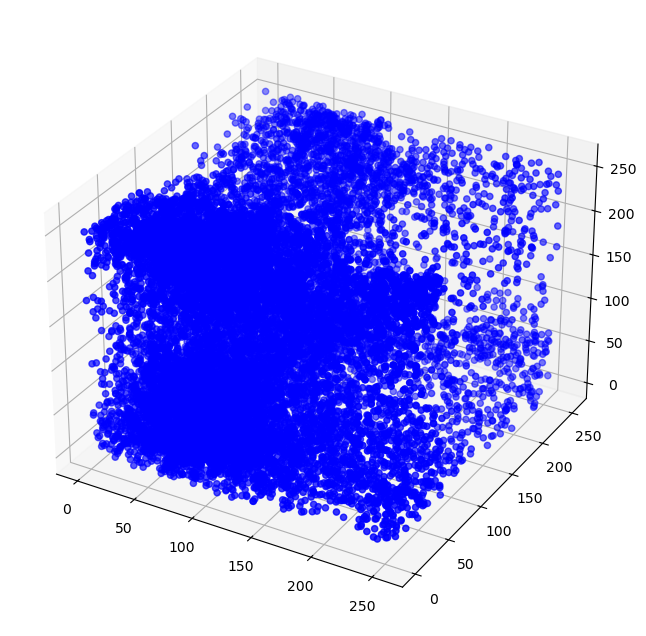

In [83]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(positions[:,0], positions[:,1], positions[:,2], color='blue')
plt.show()

In [88]:
positions = np.loadtxt("crosslinks-positions.txt")

# Load connection table (first column = ID, next columns = connected IDs)
connections = np.loadtxt("connected_xlinks.txt", skiprows=1, delimiter="\t", dtype=int)

pos = positions[0] % 256
len(connections)

16130

# Save the final position of the crosslinks

In [37]:
np.savetxt("final_positions.txt",xlink_position,
           fmt="%.3f %.3f %.3f",
           header="ID X Y Z",
           comments='')  # comments='' avoids the default '#' before header

# TOY MODEL: lattice

Monte Carlo smoothing finished in 53 steps. Max displacement: 0.00000000000000000000000000000000000000000000000000
[[   1.    0.    0.    0.]
 [   2.    0.    0.   10.]
 [   3.    0.    0.   20.]
 ...
 [ 998.   90.   90.   70.]
 [ 999.   90.   90.   80.]
 [1000.   90.   90.   90.]]


Text(0.5, 0.92, 'Equilibrium')

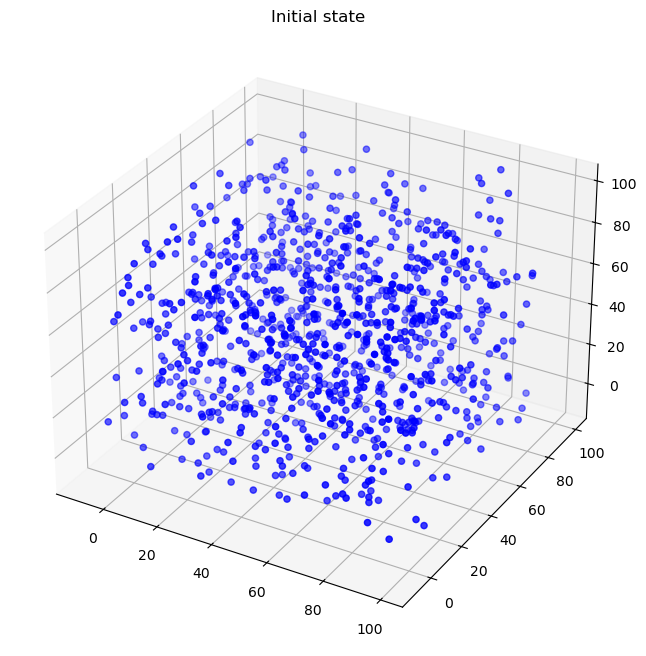

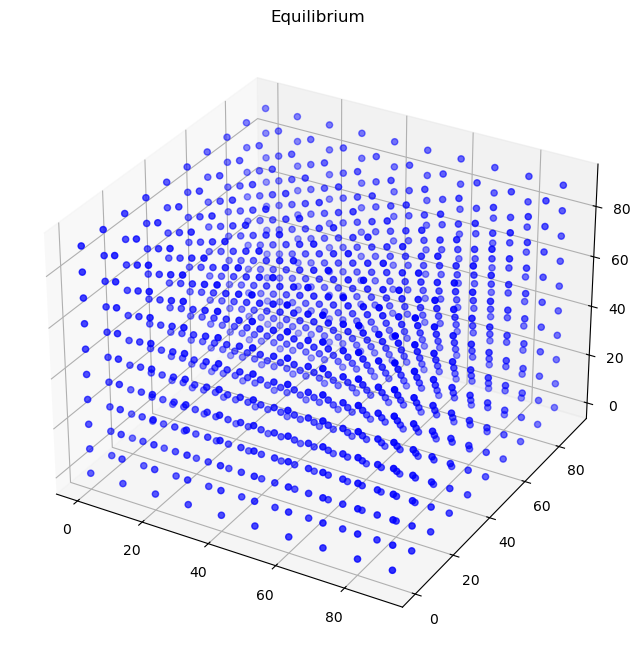

In [4]:
import numpy as np
import matplotlib.pyplot as plt
cube_size = np.array([100, 100, 100])
points_per_axis = 10
total_points = 1000

# Monte Carlo parameters
max_steps = 10000
tolerance = 1e-15 # convergence criterion

# 1. Create cubic lattice
coords_x = np.linspace(0, cube_size[0], points_per_axis, endpoint=False)
coords_y = np.linspace(0, cube_size[1], points_per_axis, endpoint=False)
coords_z = np.linspace(0, cube_size[2], points_per_axis, endpoint=False)
x, y, z = np.meshgrid(coords_x, coords_y, coords_z, indexing='ij')
lattice_positions = np.vstack([x.ravel(), y.ravel(), z.ravel()]).T

# 2. Add initial random noise
current_positions = lattice_positions + np.random.uniform(-10, 10, lattice_positions.shape)

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(current_positions[:,0], current_positions[:,1], current_positions[:,2], color='blue')
plt.title("Initial state")

# 3. Monte Carlo averaging loop using Fisher-Yates for random update order
step = 0
max_displacement = np.inf
L = cube_size

while max_displacement > tolerance and step < max_steps:
    max_displacement = 0.0

    indices = np.random.permutation(np.arange(total_points))

    # Update each point individually
    for i in indices:
        # Ensure current position is inside the box
        current_positions[i] = current_positions[i] % L

        # Compute periodic displacement toward lattice (minimum image)
        delta = lattice_positions[i] - current_positions[i]
        delta = (delta + 0.5 * L) % L - 0.5 * L

        # Move halfway toward lattice
        new_pos = current_positions[i] + 0.5 * delta
        new_pos = new_pos % L

        # Compute displacement magnitude for convergence check
        displacement = np.linalg.norm(delta / 2)
        if displacement > max_displacement:
            max_displacement = displacement

        # Update position
        current_positions[i] = new_pos

    step += 1
    #np.savetxt("testfile-"+str(step)+".txt",indices)
# 4. Combine IDs with smoothed positions
ids = np.arange(1, total_points + 1).reshape(-1, 1)
points_with_ids = np.hstack([ids, current_positions])

print(f"Monte Carlo smoothing finished in {step} steps. Max displacement: {max_displacement:.50f}")
print(points_with_ids.round(1))

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(points_with_ids[:,1], points_with_ids[:,2], points_with_ids[:,3], color='blue')
plt.title("Equilibrium")

# 5. Clean up
#del current_positions, lattice_positions, ids, points_with_ids
#del coords_x, coords_y, coords_z, x, y, z, positions, indices, L

# Test_system.dat have all the connections, Test_system2.dat changed 104 -> 0 (lower connectivity)

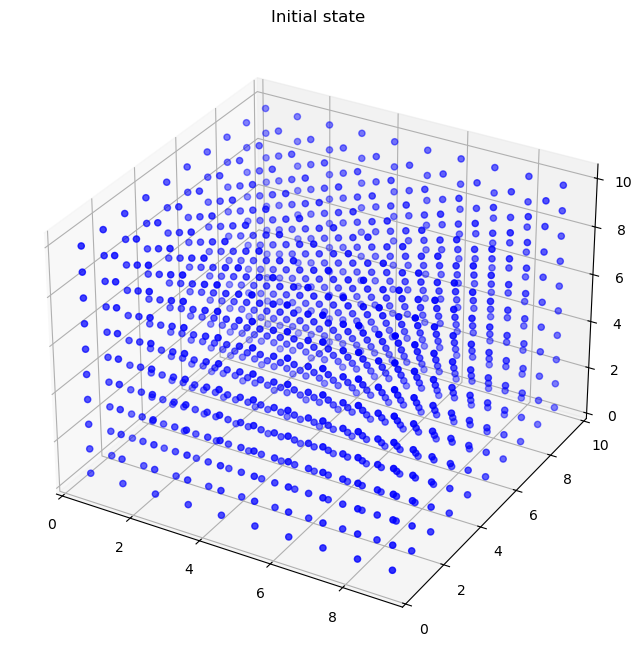

In [118]:
import numpy as np
import matplotlib.pyplot as plt


bonds = []
positions = []

with open("test_system2.dat", "r") as f:
    before_symbol = True
    for line in f:
        if "!" in line:        # line that contains '!'
            before_symbol = False
            continue
        
        parts = line.split()   # split into individual numbers
        
        if before_symbol:
            bonds.append(parts)
        else:
            positions.append(parts)

bonds = np.array(bonds, dtype=float)       # shape (N, 2)
bonds = bonds.astype(int)
positions = np.array(positions, dtype=float)  # shape (M, 3)



fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(positions[:,0], positions[:,1], positions[:,2], color='blue')

if False:
    for i, j in bonds:
        x = [positions[i-1,0], positions[j-1,0]]
        y = [positions[i-1,1], positions[j-1,1]]
        z = [positions[i-1,2], positions[j-1,2]]
        ax.plot(x, y, z, color='red') 
plt.title("Initial state")
plt.show()

Step 1: max displacement = 3.194873e-01
Step 2: max displacement = 1.217702e-01
Step 3: max displacement = 5.902220e-02
Step 4: max displacement = 4.396334e-02
Step 5: max displacement = 3.477465e-02
Step 6: max displacement = 2.878168e-02
Step 7: max displacement = 2.515310e-02
Step 8: max displacement = 2.108087e-02
Step 9: max displacement = 2.076594e-02
Step 10: max displacement = 1.545776e-02
Step 11: max displacement = 1.432087e-02
Step 12: max displacement = 1.320342e-02
Step 13: max displacement = 1.135404e-02
Step 14: max displacement = 1.106280e-02
Step 15: max displacement = 9.004807e-03
Step 16: max displacement = 9.032598e-03
Step 17: max displacement = 7.392605e-03
Step 18: max displacement = 7.376009e-03
Step 19: max displacement = 5.425276e-03
Step 20: max displacement = 5.473251e-03
Step 21: max displacement = 5.179424e-03
Step 22: max displacement = 4.170571e-03
Step 23: max displacement = 4.233830e-03
Step 24: max displacement = 3.497400e-03
Step 25: max displacement

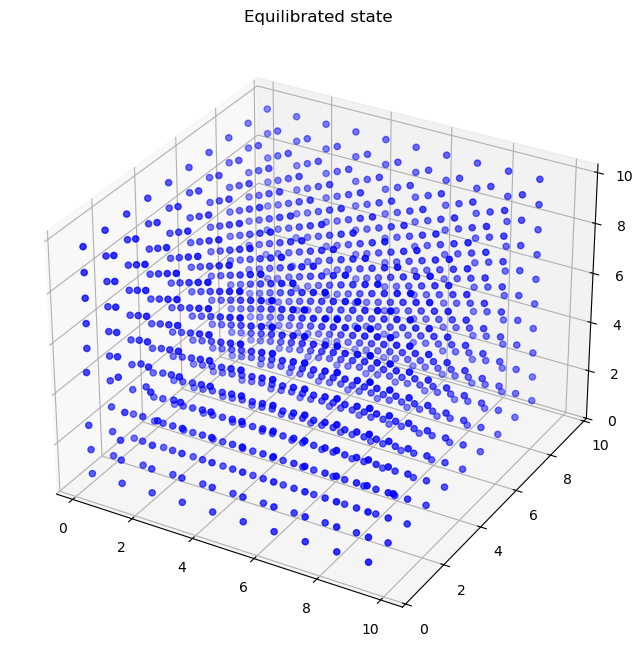

In [119]:
max_steps = 1000
tolerance = 1e-8  # convergence criterion (adjust as needed)

step = 0
max_displacement = np.inf
# box length (scalar) used in many toy sections above; if you have per-axis boxes use an array like [Lx, Ly, Lz]
L = 10
# relaxation parameter (0 < alpha <= 1). alpha=0.5 moves halfway toward COM (stable).
alpha = 1

# make box an array for component-wise ops (works if L is scalar or array)
box = np.asarray(L) if np.ndim(L) > 0 else np.array([L, L, L])

while max_displacement > tolerance and step < max_steps:
    max_displacement = 0.0

    # random update order helps Monte Carlo convergence (Fisher-Yates via np.random.permutation)
    indices = np.random.permutation(len(positions))

    for i in indices:  # run over xlinks
        pos = positions[i] % box

        # accumulate neighbor displacements using minimum-image convention
        sum_delta = np.zeros(pos.shape)
        count = 0

        for j in range(len(bonds)):
                    # check if i appears in this bond
            for k in range(len(bonds[j])):
                if bonds[j][k] == 0: #ignore 0 indices -- no connnection
                    continue
                if int(bonds[j][k]) - 1 == i:
                            # map the other two positions in the bond
                    for other_idx in range(len(bonds[j])):
                        if bonds[j][other_idx] == 0: #ignore 0 indices -- no connnection
                            continue
                        if other_idx != k:
                            conn_idx = int(bonds[j][other_idx]) - 1
                            conn_pos = positions[conn_idx] % box
                            delta = conn_pos - pos
                            delta = (delta + 0.5 * box) % box - 0.5 * box  # minimum-image
                            sum_delta += delta
                            count += 1

                # compute average displacement
        if count == 0:
            COM = np.zeros_like(pos)
        else:
            COM = sum_delta / count

                # move fully toward neighbors (alpha=1)
        new_pos = (pos + COM) % box
        positions[i] = new_pos

        displacement = np.linalg.norm(COM)
        if displacement > max_displacement:
            max_displacement = displacement
    step += 1
    print(f"Step {step}: max displacement = {max_displacement:.6e}")
    

# optional quick plot of equilibrated positions
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(positions[:,0], positions[:,1], positions[:,2], color='blue')

if False:
    for i, j in bonds:
        x = [positions[i-1,0], positions[j-1,0]]
        y = [positions[i-1,1], positions[j-1,1]]
        z = [positions[i-1,2], positions[j-1,2]]
        ax.plot(x, y, z, color='red') 
plt.title("Equilibrated state")
plt.show()



In [120]:
np.savetxt("final_positions-test_system2.txt",positions,
           fmt="%.3f %.3f %.3f",
           header="X Y Z",
           comments='')  # comments='' avoids the default '#' before header

In [1]:
delta = [1,2,3]
delta[0]

1